# MACD Research

In [88]:
import pandas as pd
pd.options.plotting.backend = "plotly"

from datetime import datetime, timedelta
import pytz

import pathlib
import numpy as np
np.random.seed(42)

## Get the data

In [89]:
data_path = pathlib.Path().joinpath("../../data/crypto/coinbase/daily/btcusd.csv").resolve()
df = pd.read_csv(data_path, 
                 names=["datetime", "open", "high", "low", "close", "volume"], 
                 header=None, parse_dates=True, index_col='datetime')


In [103]:
df['ts'] = df.index
df = df.iloc[-365:]

In [104]:
df.head()

,open,high,low,close,volume,ts,macd,macd_signal,macd_hist
datetime,,,,,,,,,
2024-01-02,44220.78,45925.82,44195.13,44972.80,29583.384077,2024-01-02,2.906916,2.851949,0.054968
2024-01-03,44972.81,45519.32,40625.68,42862.44,32281.665338,2024-01-03,2.904722,2.856008,0.048714
2024-01-04,42860.58,44800.00,42650.00,44193.29,18191.657019,2024-01-04,2.904907,2.859770,0.045137
2024-01-05,44198.35,44443.37,42450.00,44186.59,18072.276032,2024-01-05,2.904120,2.863181,0.040939
2024-01-06,44187.76,44260.95,43436.50,43992.44,5691.434603,2024-01-06,2.903594,2.866290,0.037304


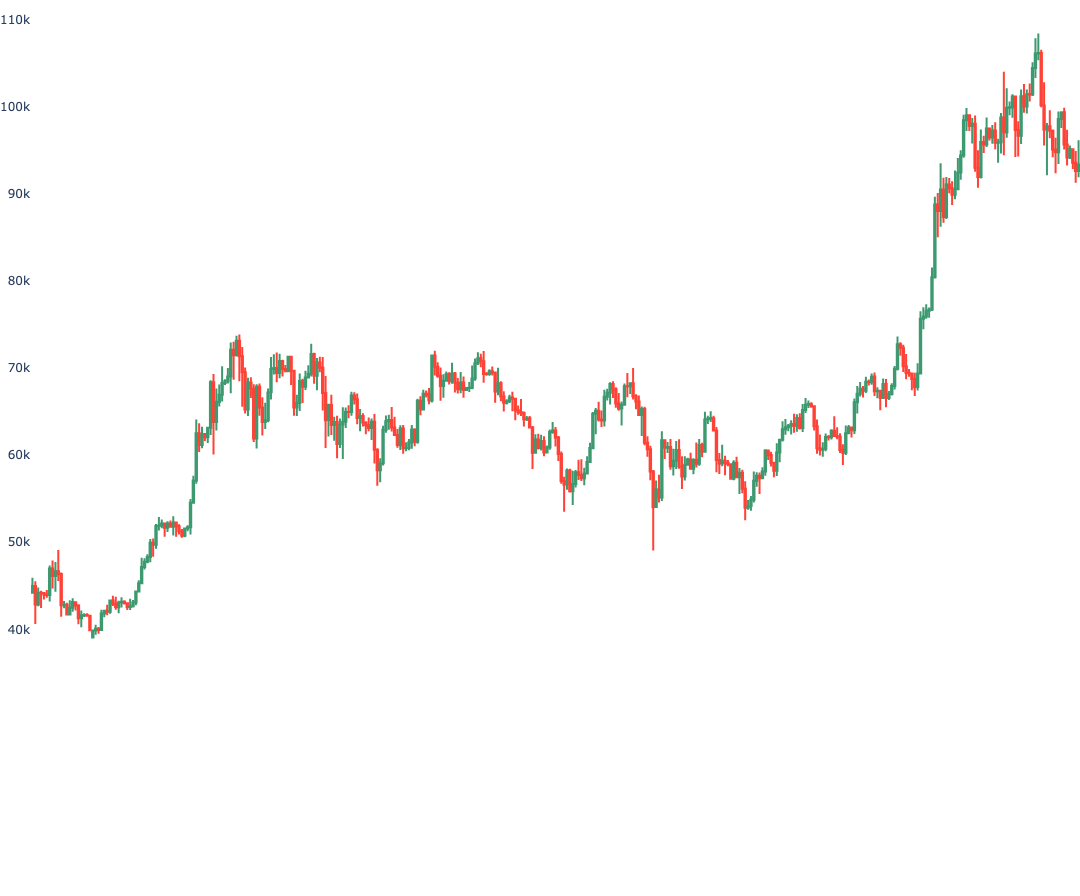

In [105]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
    
def plot(df):
    # Create figure with secondary y-axis
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0
        #specs=[[{"secondary_y": True}]]
    )

    # include candlestick with rangeselector
    fig.add_trace(go.Candlestick(
            x=df['ts'],
            open=df['open'], 
            high=df['high'],
            low=df['low'], 
            close=df['close']
        ),
        row=1, col=1
    )

    # include a go.Bar trace for volumes
    # fig.add_trace(go.Bar(
    #         x=df['ts'], 
    #         y=df['volume'],
    #         opacity=0.5,
    #         marker_color=list(df.apply(lambda r: 'rgb(0, 255, 0)' if r['close'] >= r['open'] else 'rgb(255, 0, 0)', axis=1)) #'rgb(0, 0, 255)'
    #     ), 
    #     row=2, col=1
    # )

    # fig.layout.yaxis.showgrid=False
    # fig.layout.yaxis2.showgrid=False
    # fig.update_yaxes(showticklabels=False)
    # fig.update_xaxes(showticklabels=False)

    fig.update_layout(
        xaxis_rangeslider_visible=False,
        showlegend=False,
        autosize=True,
        margin=dict(
            l=0,
            r=0,
            b=0,
            t=0,
            pad=0
        ),
        # paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='#fff', #'rgba(0,0,0,0)',
        height=224*4,
    )
    
    return fig

plot(df).show()

## MACD Calculation

In [ ]:
import optuna

def calculate_macd(df,
                   ema_short_length=12,
                   ema_long_length=26,
                   signal_length=9):
    df_t = df.copy()
    df_t['ema_short'] = ((df_t['high'] + df_t['low'] + df_t['close']) / 3).ewm(span=ema_short_length, min_periods=ema_short_length).mean()
    df_t['ema_long'] = ((df_t['high'] + df_t['low'] + df_t['close']) / 3).ewm(span=ema_long_length, min_periods=ema_long_length).mean()
    df['macd'] = df_t['ema_short'] - df_t['ema_long']
    df['macd_signal'] = df['macd'].ewm(span=signal_length, adjust=False).mean()
    df['macd_hist'] = (df['macd'] - df['macd_signal']) / (df['macd'] - df['macd_signal']).std()
    df['macd'] = df['macd'] / df['macd'].std()
    df['macd_signal'] = df['macd_signal'] / df['macd_signal'].std()

    return df

def calculate_macd_fitness(df):
    df_f = df.copy()
    df_f['tr_next'] = ((df_f['close'] + df_f['high'] + df_f['low']) / 3.).shift(-1)
    c = df_f[['tr_next', 'macd_hist']].corr()['tr_next']['macd_hist']

    return c

def objective(trial, df):
    df_tmp = df.copy()
    
    ema_short_length = trial.suggest_int("ema_short_length", 6, 24)
    df_tmp = calculate_macd(df_tmp, 
        ema_short_length=ema_short_length,
        ema_long_length=trial.suggest_int("ema_long_length", ema_short_length+1, 52),
        signal_length=trial.suggest_int("signal_length", 5, 18),
    )
    
    return calculate_macd_fitness(df_tmp)


# study = optuna.create_study(direction='maximize')
# study.optimize(lambda t: objective(t, df), n_trials=250)
# print(study.best_params)

df_macd = calculate_macd(
    df, 
    ema_short_length=12,
    ema_long_length=26,
    signal_length=9
)

In [107]:
def calculate_macd(df, ema_short_length=12, ema_long_length=26, signal_length=9):
    df_t = df.copy()
    df_t['ema_short'] = ((df_t['high'] + df_t['low'] + df_t['close']) / 3).ewm(span=ema_short_length, min_periods=ema_short_length).mean()
    df_t['ema_long'] = ((df_t['high'] + df_t['low'] + df_t['close']) / 3).ewm(span=ema_long_length, min_periods=ema_long_length).mean()
    
    df['macd'] = 100 * (1 - df_t['ema_long'] / df_t['ema_short'])
    df['macd'] = np.sign(df['macd']) * np.log1p(np.abs(df['macd']))
    df['macd_signal'] = df['macd'].ewm(span=signal_length, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']

    return df

In [108]:
# df_macd = calculate_macd(
#     df, 
#     ema_short_length=12,
#     ema_long_length=26,
#     signal_length=9
# )

df_macd = calculate_macd(
    df, 
    ema_short_length=50,
    ema_long_length=200,
    signal_length=25
)

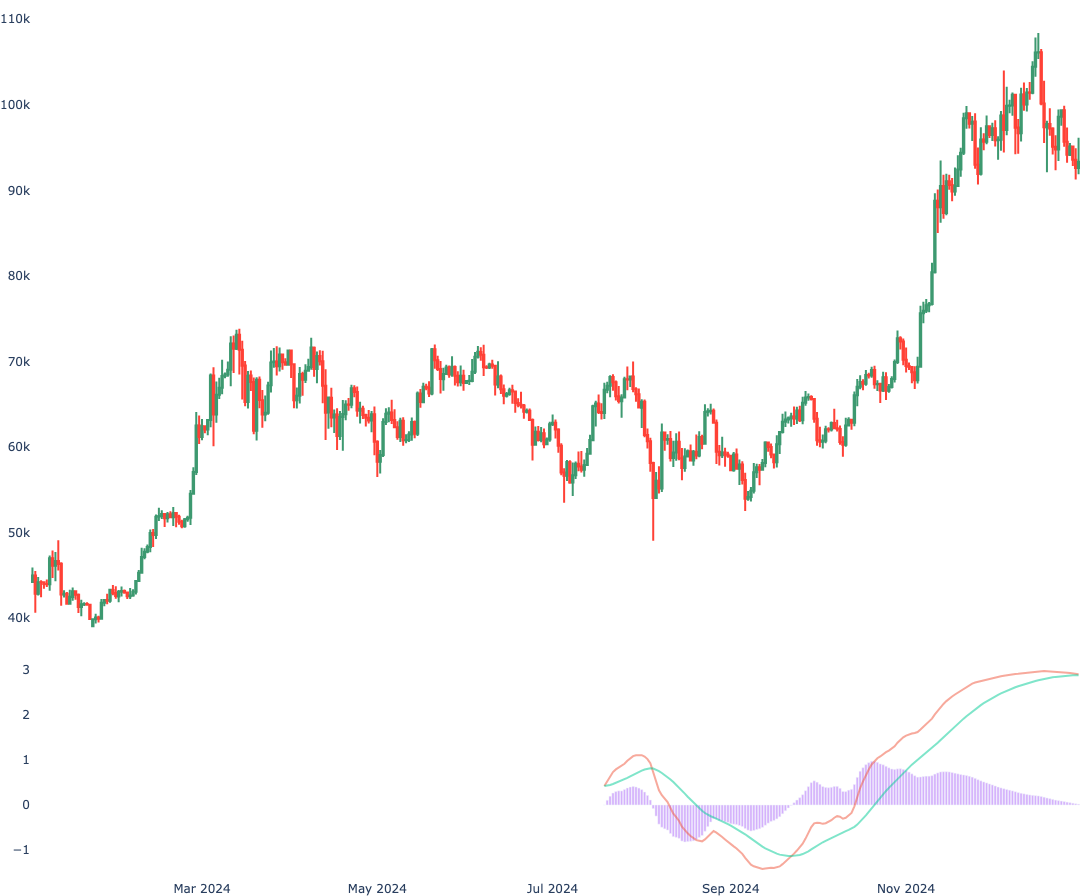

In [109]:
fig = plot(df_macd)
fig.add_trace(go.Scatter(
        x=df_macd['ts'], 
        y=df_macd['macd'],
        opacity=0.5,
        mode='lines',
        name='MACD'
    ), 
    row=2, col=1
)
fig.add_trace(go.Scatter(
        x=df_macd['ts'], 
        y=df_macd['macd_signal'],
        opacity=0.5,
        mode='lines',
        name='SIGNAL'
    ), 
    row=2, col=1
)
fig.add_trace(go.Bar(
        x=df_macd['ts'], 
        y=df_macd['macd_hist'],
        opacity=0.5,
        name='H'
    ), 
    row=2, col=1
)

fig.show()